In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
btc_raw = pd.read_csv("BTC_full_data.csv")
eth_raw = pd.read_csv("ETH_full_data.csv")

In [3]:

# ----------------------------
# 1) prepare df
# ----------------------------
def prepare_price_data(df, date_col="Date"):
    out = df.copy()
    out[date_col] = pd.to_datetime(out[date_col])
    out = out.sort_values(date_col).reset_index(drop=True)
    return out

btc = prepare_price_data(btc_raw)
eth = prepare_price_data(eth_raw)


In [4]:

# ----------------------------
# 2) MACD indicator
# ----------------------------
def add_macd(data, a=12, b=26, c=9, price_col="Close"):
    out = data.copy()

    if a >= b:
        raise ValueError("Need a < b for MACD.")

    out["ema_fast"] = out[price_col].ewm(span=a, adjust=False).mean()
    out["ema_slow"] = out[price_col].ewm(span=b, adjust=False).mean()
    out["macd"] = out["ema_fast"] - out["ema_slow"]
    out["signal"] = out["macd"].ewm(span=c, adjust=False).mean()
    out["hist"] = out["macd"] - out["signal"]

    return out

# ----------------------------
# 3) Position logic
# ----------------------------
def make_position(macd, signal, mode="long_flat", buffer=0.0):
    spread = macd - signal

    if mode == "long_flat":
        pos = np.where(spread > buffer, 1, 0)

    elif mode == "long_short":
        pos = np.where(spread > buffer, 1, -1)

    elif mode == "long_short_flat":
        pos = np.where(
            spread > buffer, 1,
            np.where(spread < -buffer, -1, 0)
        )

    else:
        raise ValueError("mode must be 'long_flat', 'long_short', or 'long_short_flat'")

    return pd.Series(pos, index=macd.index)

# ----------------------------
# 4) Backtest
# ----------------------------
def backtest_macd(
    data,
    a=12,
    b=26,
    c=9,
    mode="long_flat",
    buffer=0.0,
    fee=0.0,
    price_col="Close",
    rf_annual=0.03
):
    out = add_macd(data, a=a, b=b, c=c, price_col=price_col)

    out["ret"] = out[price_col].pct_change().fillna(0)

    raw_pos = make_position(out["macd"], out["signal"], mode=mode, buffer=buffer)

    # use yesterday's signal for today's position
    out["position"] = raw_pos.shift(1).fillna(0)

    out["trade"] = out["position"].diff().abs().fillna(0)
    out["strategy_ret"] = out["position"] * out["ret"] - out["trade"] * fee

    out["equity_curve"] = (1 + out["strategy_ret"]).cumprod()
    out["cumulative_pnl"] = out["equity_curve"] - 1

    out["running_max"] = out["equity_curve"].cummax()
    out["drawdown"] = out["equity_curve"] / out["running_max"] - 1

    n = len(out)
    years = n / 365.25

    cumulative_pnl = out["cumulative_pnl"].iloc[-1]
    average_daily_pnl = out["strategy_ret"].mean()
    max_drawdown = out["drawdown"].min()
    annualised_return = out["equity_curve"].iloc[-1] ** (1 / years) - 1 if years > 0 else np.nan

    daily_std = out["strategy_ret"].std()
    annualised_volatility = daily_std * np.sqrt(365)

    rf_daily = (1 + rf_annual) ** (1 / 365) - 1
    excess_daily = out["strategy_ret"] - rf_daily
    sharpe_ratio = (excess_daily.mean() / daily_std) * np.sqrt(365) if daily_std > 0 else np.nan

    summary = {
        "mode": mode,
        "buffer": buffer,
        "a": a,
        "b": b,
        "c": c,
        "cumulative_pnl": cumulative_pnl,
        "average_daily_pnl": average_daily_pnl,
        "max_drawdown": max_drawdown,
        "annualised_return": annualised_return,
        "sharpe_ratio_rf_3pct": sharpe_ratio,
        "daily_std_dev": daily_std,
        "annualised_volatility": annualised_volatility,
    }

    return out, summary

# ----------------------------
# 5) Parameter search
# ----------------------------
def search_macd_parameters(
    data,
    a_values,
    b_values,
    c_values,
    mode="long_flat",
    buffer=0.0,
    fee=0.0,
    price_col="Close",
    rf_annual=0.03,
    sort_by=("sharpe_ratio_rf_3pct", "annualised_return")
):
    results = []

    for a in a_values:
        for b in b_values:
            if a >= b:
                continue
            for c in c_values:
                _, summary = backtest_macd(
                    data=data,
                    a=a,
                    b=b,
                    c=c,
                    mode=mode,
                    buffer=buffer,
                    fee=fee,
                    price_col=price_col,
                    rf_annual=rf_annual
                )
                results.append(summary)

    results_df = pd.DataFrame(results).sort_values(
        list(sort_by), ascending=False
    ).reset_index(drop=True)

    return results_df

In [6]:
def run_asset_search(asset_df, asset_name):
    results = search_macd_parameters(
        data=asset_df,
        a_values=range(6, 19, 2),
        b_values=range(20, 51, 5),
        c_values=range(5, 16, 2),
        mode="long_flat",
        buffer=0.0,
        fee=0.0,
        price_col="Close",
        rf_annual=0.03
    )

    best = results.iloc[0]

    print(f"\nTop 10 for {asset_name}")
    print(results.head(10).round(4))

    print(f"\nBest params for {asset_name}")
    for k, v in best.items():
        if isinstance(v, (float, np.floating)):
            print(f"{k:25s}: {v:.4f}")
        else:
            print(f"{k:25s}: {v}")

    return results, best

In [8]:
btc_results, btc_best = run_asset_search(btc, "BTC")
eth_results, eth_best = run_asset_search(eth, "ETH")


Top 10 for BTC
        mode  buffer   a   b   c  cumulative_pnl  average_daily_pnl  \
0  long_flat     0.0  16  20  15         20.9478             0.0013   
1  long_flat     0.0  18  20  11         20.6979             0.0013   
2  long_flat     0.0  18  50  13         20.2858             0.0013   
3  long_flat     0.0  12  25  15         19.5901             0.0013   
4  long_flat     0.0  14  20  15         19.2145             0.0013   
5  long_flat     0.0  18  20  15         19.2612             0.0013   
6  long_flat     0.0  16  25  11         18.9244             0.0013   
7  long_flat     0.0  14  25  13         18.8694             0.0013   
8  long_flat     0.0  16  20  13         18.8466             0.0013   
9  long_flat     0.0  18  25   9         18.2626             0.0013   

   max_drawdown  annualised_return  sharpe_ratio_rf_3pct  daily_std_dev  \
0       -0.5637             0.4714                1.0210         0.0233   
1       -0.5632             0.4693                1.

In [16]:
eth_best

mode                     long_flat
buffer                         0.0
a                               18
b                               50
c                               13
cumulative_pnl           53.419766
average_daily_pnl         0.001842
max_drawdown             -0.614735
annualised_return         0.648329
sharpe_ratio_rf_3pct      1.089449
daily_std_dev             0.030889
annualised_volatility     0.590129
Name: 0, dtype: object

In [17]:
best_eth_bt, best_eth_summary = backtest_macd(
    data=eth,
    a=int(eth_best["a"]),
    b=int(eth_best["b"]),
    c=int(eth_best["c"]),
    mode=eth_best["mode"],
    buffer=float(eth_best["buffer"]),
    fee=0.0,
    price_col="Close",
    rf_annual=0.03
)

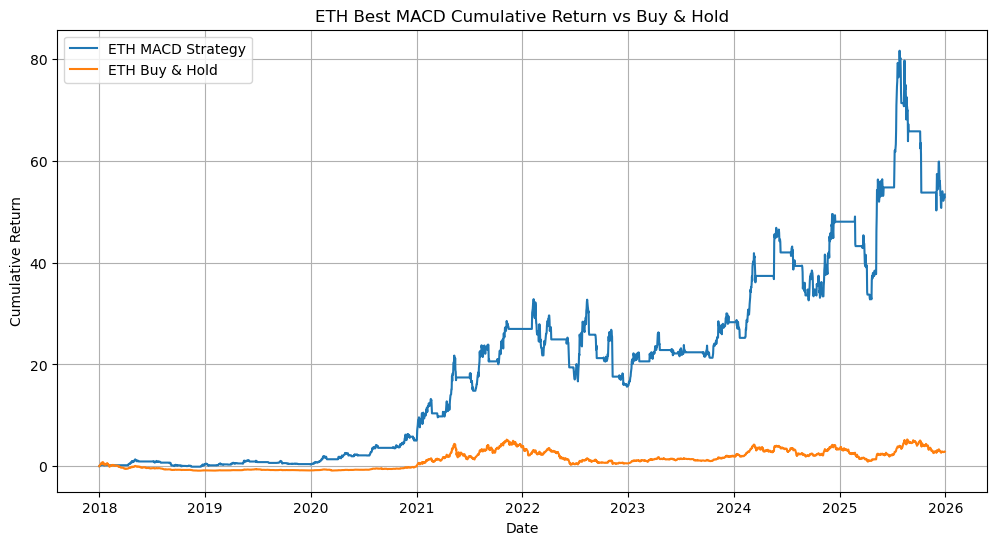

In [19]:
plt.figure(figsize=(12, 6))
plt.plot(best_eth_bt["Date"], best_eth_bt["cumulative_pnl"], label="ETH MACD Strategy")
plt.plot(best_eth_bt["Date"], best_eth_bt["buy_hold_curve"] - 1, label="ETH Buy & Hold")
plt.title("ETH Best MACD Cumulative Return vs Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.show()

In [9]:
btc_best

mode                     long_flat
buffer                         0.0
a                               16
b                               20
c                               15
cumulative_pnl           20.947787
average_daily_pnl         0.001327
max_drawdown             -0.563726
annualised_return         0.471402
sharpe_ratio_rf_3pct      1.021047
daily_std_dev             0.023312
annualised_volatility     0.445369
Name: 0, dtype: object

In [10]:
best_bt, best_summary = backtest_macd(
    data=btc,
    a=16,
    b=20,
    c=15,
    mode="long_flat",
    buffer=0.0,
    fee=0.0,
    price_col="Close",
    rf_annual=0.03
)

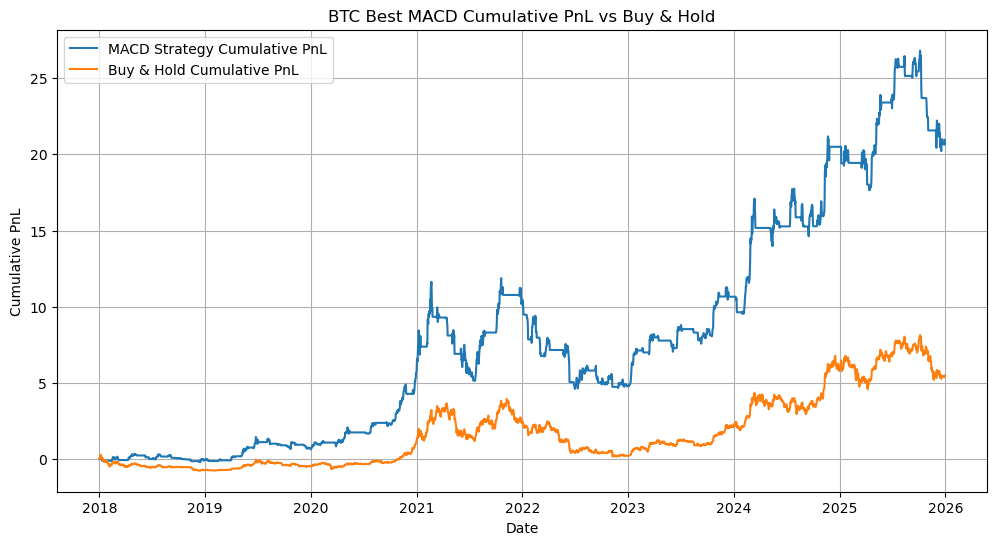

In [12]:
plt.figure(figsize=(12, 6))
plt.plot(best_bt["Date"], best_bt["cumulative_pnl"], label="MACD Strategy Cumulative PnL")
plt.plot(best_bt["Date"], best_bt["buy_hold_curve"] - 1, label="Buy & Hold Cumulative PnL")
plt.title("BTC Best MACD Cumulative PnL vs Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Cumulative PnL")
plt.legend()
plt.grid(True)
plt.show()